### A1 Cost Map

  [cache] Loading costmap_A1_1_50m.gpkg from disk (use force_rebuild=True to rebuild)
  [cache] Loading costmap_A1_2_50m.gpkg from disk (use force_rebuild=True to rebuild)


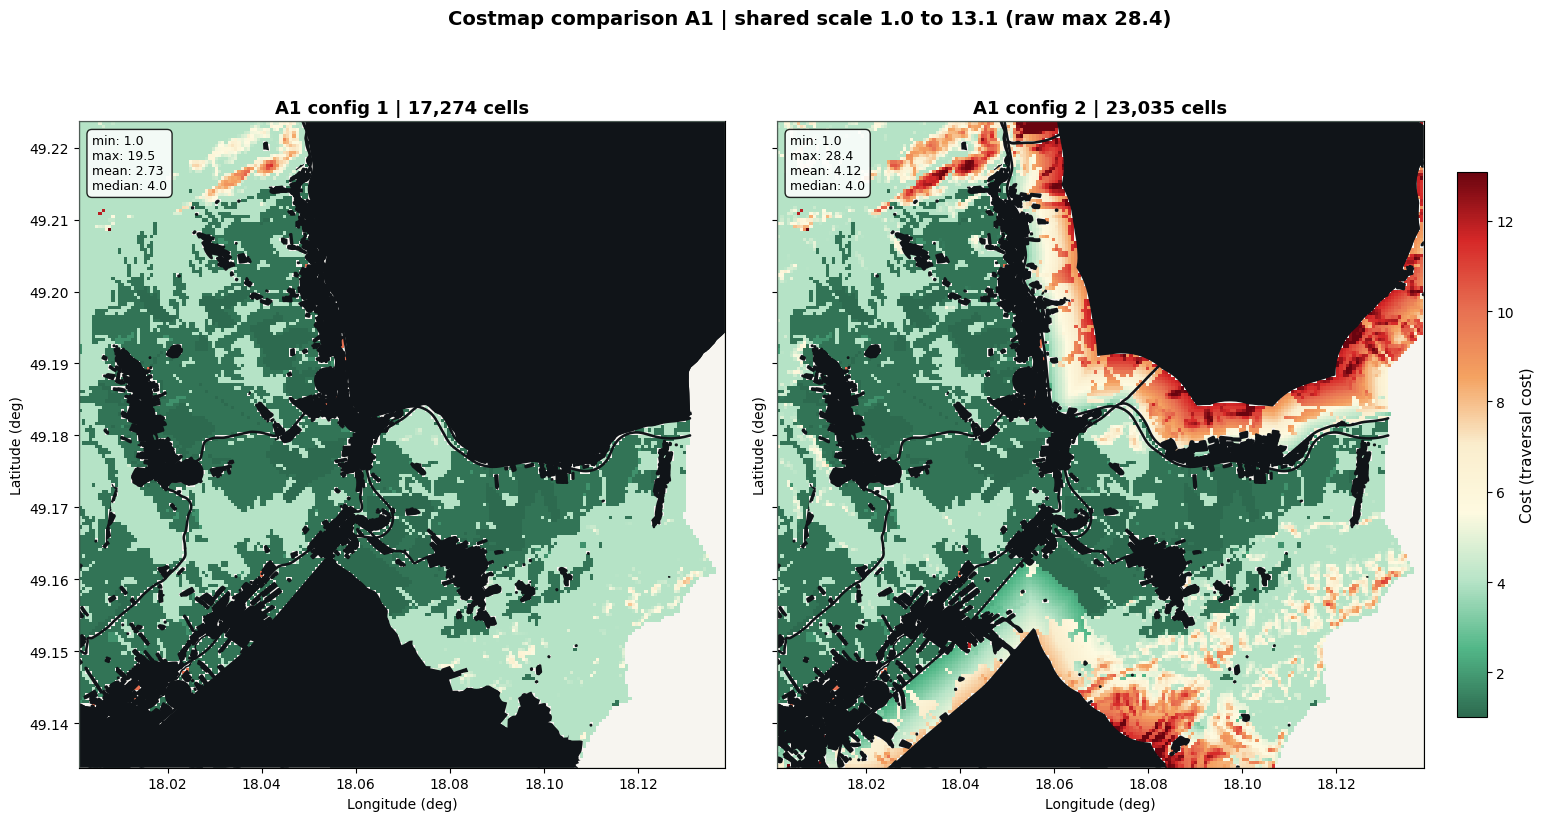

In [2]:
"""
Build and compare two square costmaps for A1.
Each scenario uses its own config module and both outputs share one color scale.
"""

import sys
from pathlib import Path

sys.path.insert(0, str(Path("../").resolve()))

from src.costmap_builder import build_costmaps_for_scenarios
from src.map_plot import plot_costmaps_side_by_side

AREA_LABEL = "A1"
GEOJSON_PATH = Path("../data_A1.geojson")
GPKG_PATH = Path("../data/raw/ZABAGED_RESULTS.gpkg")
OUTPUT_DIR = Path("../data/processed/A1")
CELL_SIZE = 50

SCENARIOS = [
    {"module": "config_costs_A1_1", "label": "A1 config 1", "export_prefix": "costmap_A1_1"},
    {"module": "config_costs_A1_2", "label": "A1 config 2", "export_prefix": "costmap_A1_2"},
]

scenario_results = build_costmaps_for_scenarios(
    SCENARIOS,
    GEOJSON_PATH,
    GPKG_PATH,
    OUTPUT_DIR,
    CELL_SIZE,
)
plot_costmaps_side_by_side(scenario_results, AREA_LABEL)



DIJKSTRA A1 config 1
Start coord: (18.01, 49.16) -> square cell_id=3927
Goal  coord: (18.11, 49.14) -> square cell_id=84
Start and Goal are outside exclusion zones.
  [A1 config 1] Building graph (17,274 nodes)... 64,920 direct + 15,836 jump edges (76 blocked by can_cross) (2.0 s)
  [A1 config 1] Turn penalty active: 9 dirs x 11 jumps = 1,710,126 states (~28 MB)
  [A1 config 1] Running Dijkstra (1,710,126 states)... 1,359,610 expansions (18.1 s)
Total cost: 412.5 | 175 cells | ~10,448 m | jumps: 0x | turns: 18 | 20.20 s total

DIJKSTRA A1 config 2
Start coord: (18.01, 49.16) -> square cell_id=6465
Goal  coord: (18.11, 49.14) -> square cell_id=913
Start and Goal are outside exclusion zones.
  [A1 config 2] Building graph (23,035 nodes)... 86,297 direct + 15,836 jump edges (5,281 blocked by can_cross) (2.5 s)
  [A1 config 2] Turn penalty active: 9 dirs x 11 jumps = 2,280,465 states (~37 MB)
  [A1 config 2] Running Dijkstra (2,280,465 states)... 1,472,963 expansions (20.8 s)
Total cost: 

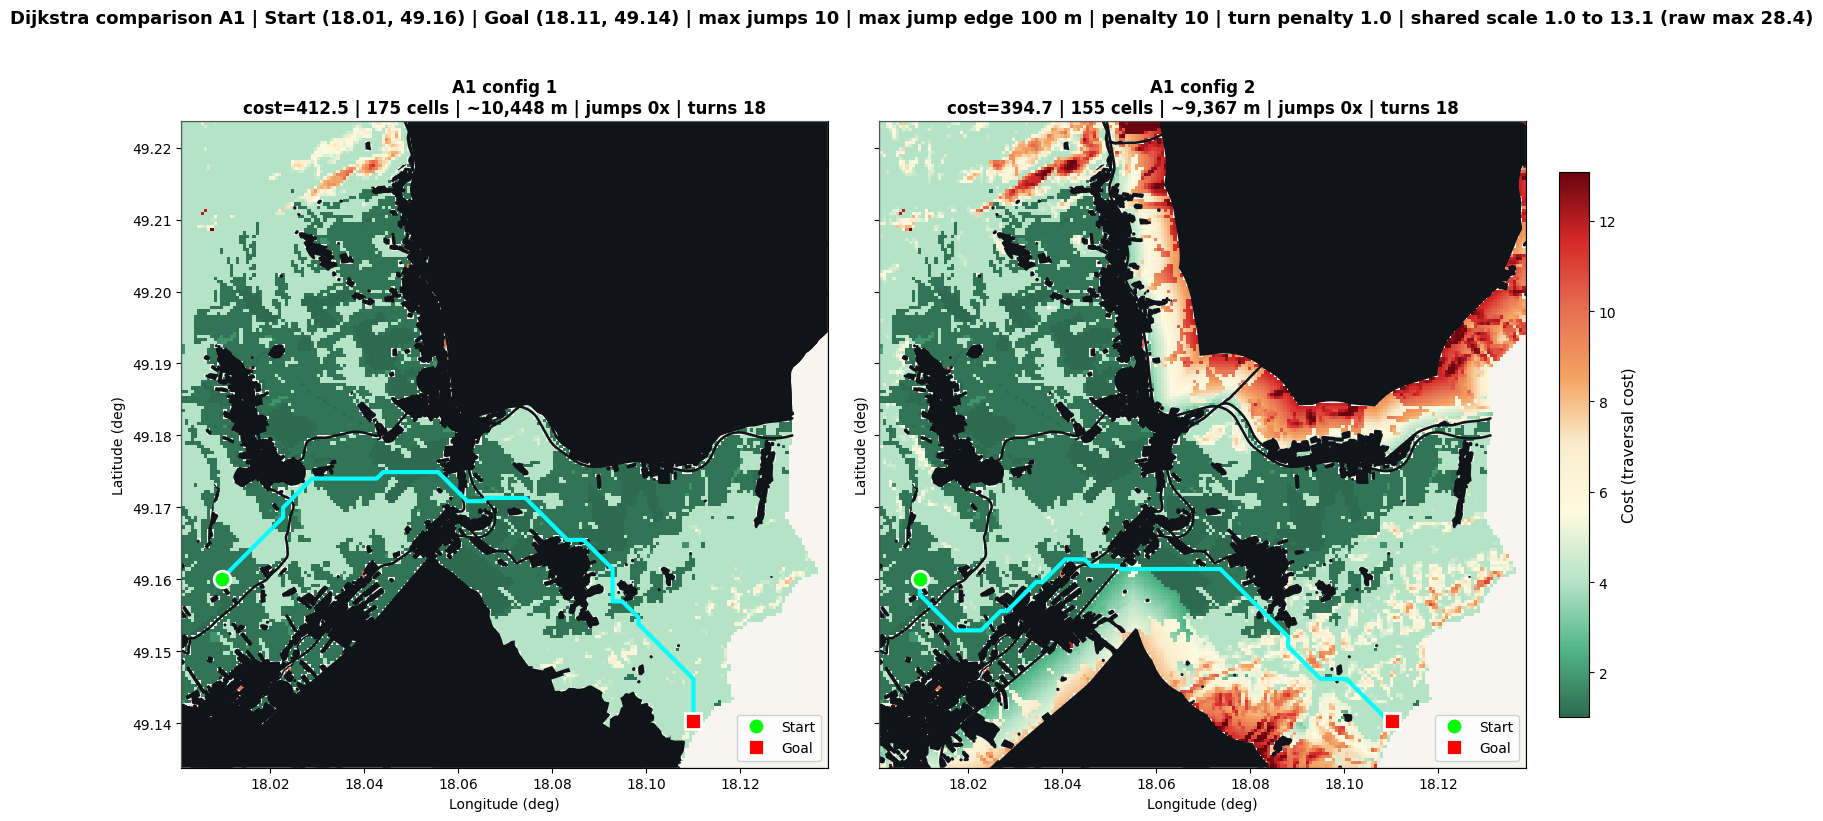

In [3]:
"""
Run and compare Dijkstra on both A1 costmaps.
Both scenarios use the same start/goal and shared visualization scaling.
"""

from src.dijkstra import run_dijkstra_for_scenarios
from src.map_plot import plot_dijkstra_side_by_side

START_LONLAT = (18.01, 49.16)
GOAL_LONLAT = (18.11, 49.14)

EXCLUSION_PENALTY = 10
MAX_JUMPS = 10
MAX_JUMP_EDGE_M = 100.0
TURN_PENALTY = 1.0

route_results = run_dijkstra_for_scenarios(
    scenario_results,
    START_LONLAT,
    GOAL_LONLAT,
    EXCLUSION_PENALTY,
    MAX_JUMPS,
    TURN_PENALTY,
    max_jump_edge_m=MAX_JUMP_EDGE_M,
)

plot_dijkstra_side_by_side(
    route_results,
    AREA_LABEL,
    START_LONLAT,
    GOAL_LONLAT,
    EXCLUSION_PENALTY,
    MAX_JUMPS,
    TURN_PENALTY,
    max_jump_edge_m=MAX_JUMP_EDGE_M,
)


In [4]:
"""
PPO inference on the 50 m costmap with forced coarse steps.
Each action moves ~300 m (virtual 8-directional coarse grid) to reduce zigzagging.
Uses route_results from cell 3 (same start/goal, same 50 m costmap).
"""
import importlib
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../").resolve()))

import ppo_routing_cnn
import src.ppo_inference as ppo_inference

importlib.reload(ppo_inference)

AREA_LABEL = globals().get("AREA_LABEL", "A1")
EXCLUSION_PENALTY = globals().get("EXCLUSION_PENALTY", 10)
MAX_JUMPS = globals().get("MAX_JUMPS", 10)
TURN_PENALTY = globals().get("TURN_PENALTY", 1.0)

MODEL_PATH = Path("../ppo_models/coarse300_12km_v4/ppo_routing_final")
PPO_SAMPLE_COUNT = 2
PPO_MAX_ATTEMPTS = 50
PPO_MAX_STEPS = 120
COARSE_STEP_M = 300

ppo_sample_results = ppo_inference.run_ppo_samples_for_scenarios(
    route_results,
    model_path=MODEL_PATH,
    n_samples=PPO_SAMPLE_COUNT,
    max_attempts=PPO_MAX_ATTEMPTS,
    exclusion_penalty=EXCLUSION_PENALTY,
    max_jumps=MAX_JUMPS,
    turn_penalty=TURN_PENALTY,
    max_steps=PPO_MAX_STEPS,
    coarse_step_m=COARSE_STEP_M,
)


  [A1 config 1] Building coarse graph (300 m steps)...
  Coarse graph (300 m): 17236/17274 nodes reachable, avg 7.0 directions/node
  Detected torch.compile() artifact - remapping _orig_mod keys...
  [A1 config 1 attempt 1] PPO: FAILED to reach goal in 120 steps (1.31s)
  [A1 config 1 attempt 2] PPO: FAILED to reach goal in 120 steps (0.60s)
  [A1 config 1 attempt 3] PPO: cost=311.1 | 115 cells | ~34,736 m | jumps=0 | turns=90 | steps=114 | 0.59s
  [A1 config 1 attempt 4] PPO: FAILED to reach goal in 120 steps (0.72s)
  [A1 config 1 attempt 5] PPO: FAILED to reach goal in 120 steps (0.70s)
  [A1 config 1 attempt 6] PPO: FAILED to reach goal in 120 steps (0.63s)
  [A1 config 1 attempt 7] PPO: FAILED to reach goal in 120 steps (0.73s)
  [A1 config 1 attempt 8] PPO: FAILED to reach goal in 120 steps (0.72s)
  [A1 config 1 attempt 9] PPO: FAILED to reach goal in 120 steps (0.66s)
  [A1 config 1 attempt 10] PPO: FAILED to reach goal in 120 steps (0.66s)
  [A1 config 1 attempt 11] PPO: FAILE

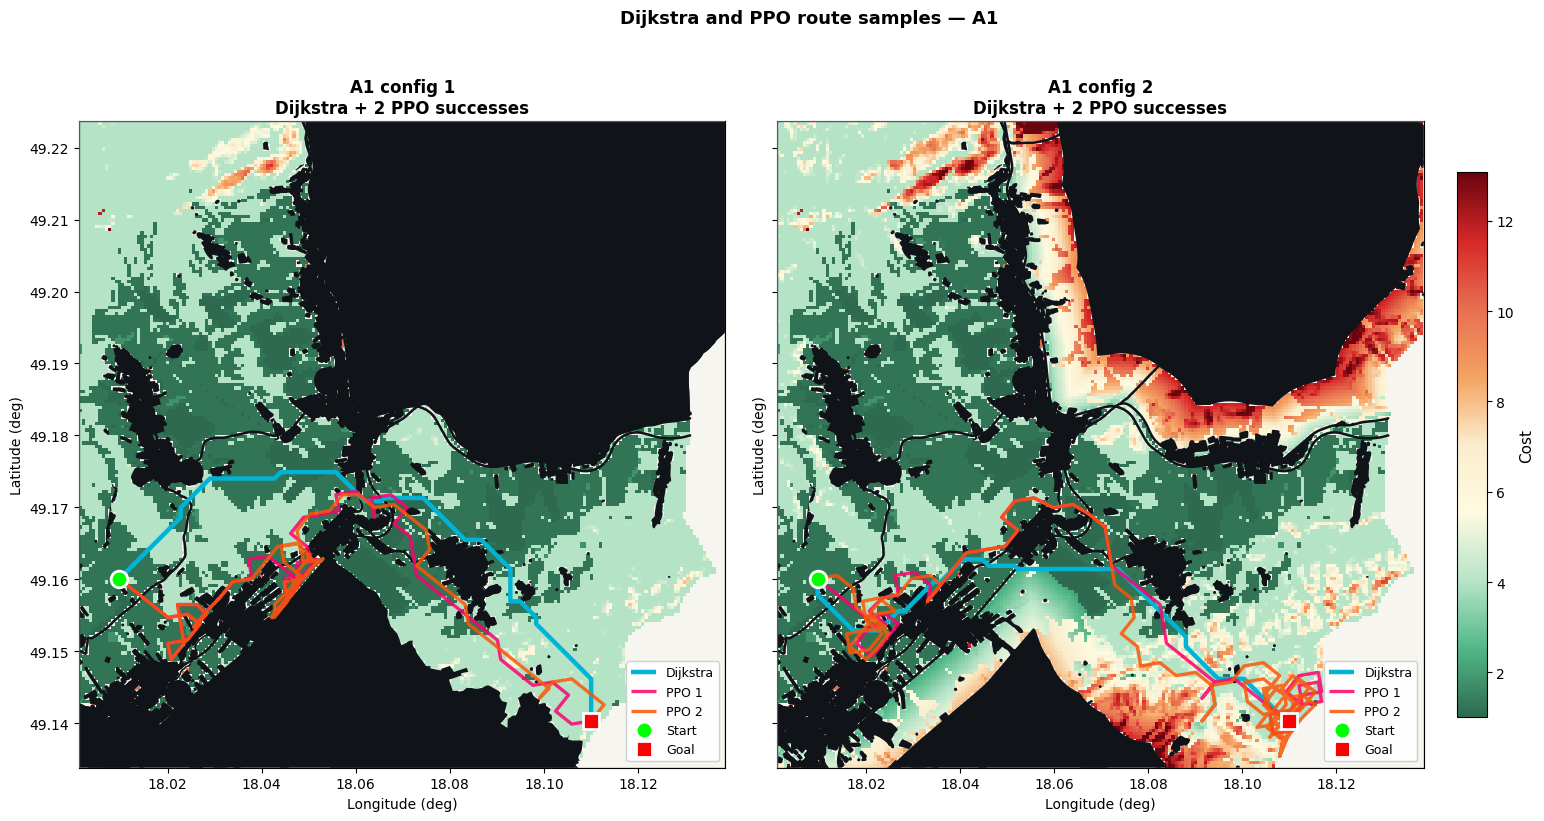

In [ ]:
import src.ppo_visualization as ppo_visualization

ppo_visualization.plot_dijkstra_with_ppo_samples(
    ppo_sample_results,
    AREA_LABEL,
    START_LONLAT,
    GOAL_LONLAT,
)
